In [1]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [ ]:
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/DYGto2LG50_24SummerRun3/b114e10b-6fe2-4bdd-af67-6351977749d1_skim.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [3]:
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/DYto2E50_24SummerRun3/05e4160d-8870-46a8-b236-8a2f4ccb44f0_skim.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events_DYE = factory.events()

In [ ]:
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/TTto2L2Nu_24SummerRun3/d2ffac1f-423a-4971-b856-f37305a6aacf_skim.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events_TTto2L2Nu = factory.events()

In [ ]:
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/TTtoLNu2Q_24SummerRun3/06466907-d31e-4c30-8795-31f94a07f1a6_skim.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events_TTtoLNu2Q = factory.events()

In [ ]:
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/TTG1Jets_24SummerRun3/9f957a6e-2a7b-43f0-8278-c7da2f4b01c2_skim.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events_TTG1Jets = factory.events()

In [ ]:
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/WGtoLNuG_24SummerRun3/d2af0eef-4f34-429a-89e9-a171af56c893_skim.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events_WGtoLNuG = factory.events()

In [ ]:
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

files = [
    "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/WtoENu0J_24SummerRun3/0efa6d26-5df8-4d77-8241-ecaa3f41cf17_skim.root",
    "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/WtoENu1J_24SummerRun3/89919590-8784-426b-a397-5d7adfd1f7c1_skim.root",
    "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/WtoENu2J_24SummerRun3/22a86834-7f76-4efb-b1db-fbc52bb2df6c_skim.root",
]

events_list = []

for file in files:
    factory = NanoEventsFactory.from_root(
        f"{file}:Events",
        schemaclass=NanoAODSchema,
    )
    events_list.append(factory.events())

events_WtoE = ak.concatenate(events_list, axis=0)

In [ ]:
files = [
    "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/WtoMuNu0J_24SummerRun3/b9de6809-5557-49d1-81bd-bfefa2f0c6d0_skim.root",
    "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/WtoMuNu1J_24SummerRun3/c945b3d9-66de-4527-8e60-1b92bcf0c668_skim.root",
    "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/WtoMuNu2J_24SummerRun3/cc327fc5-88fa-4454-909f-9ac7ee89cc82_skim.root",
]

events_list = []

for file in files:
    factory = NanoEventsFactory.from_root(
        f"{file}:Events",
        schemaclass=NanoAODSchema,
    )
    events_list.append(factory.events())

events_WtoMu = ak.concatenate(events_list, axis=0)

In [4]:
from particle import Particle

def particle_name(pdgid):
    try:
        return Particle.from_pdgid(int(pdgid)).name
    except Exception:
        return str(int(pdgid))

def print_genpart_tree(genPart, event_idx):
    particles = genPart[event_idx]
    daughters = {}
    for i in range(len(particles)):
        mother = int(particles[i].genPartIdxMother)
        if mother >= 0 and mother != i:
            daughters.setdefault(mother, []).append(i)

    def print_node(idx, prefix="", is_last=True):
        p = particles[idx]
        name = particle_name(p.pdgId)
        # pt = float(p.pt)
        # eta = float(p.eta)
        # phi = float(p.phi)
        # mass = float(p.mass)
        pt = float(p["pt"])
        eta = float(p["eta"])
        phi = float(p["phi"])
        mass = float(p["mass"])
        connector = "└── " if is_last else "├── "
        print(f"{prefix}{connector}{name}  pt={pt:.2f}  eta={eta:.2f}  phi={phi:.2f}  mass={mass:.2f}")
        children = daughters.get(idx, [])
        for j, child in enumerate(children):
            child_prefix = prefix + ("    " if is_last else "│   ")
            print_node(child, child_prefix, j == len(children) - 1)

    print("\n" + "=" * 100)
    print(f"EVENT {event_idx}")
    print("=" * 100)

    roots = [i for i in range(len(particles)) if int(particles[i].genPartIdxMother) < 0]
    for j, root in enumerate(roots):
        print_node(root, "", j == len(roots) - 1)

5630
[[1.01], [0.11], [0.222], [2.08], ..., [0.623], [0.807], [0.317], [0.185, 0.13]]
6631
[ True False False ... False False False]


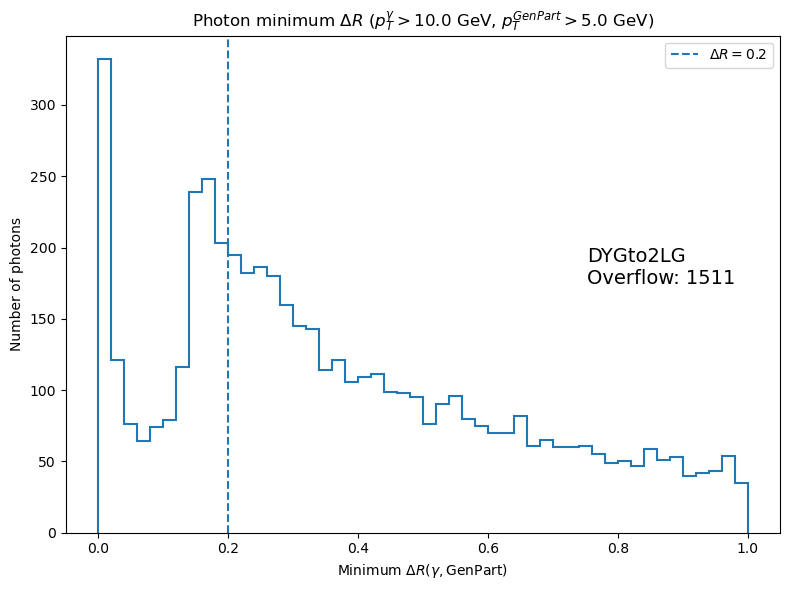

In [106]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt


def photon_min_dr(events, photon_pt_min=10.0, photon_eta_max=3.0, other_pt_min=5.0):
    gen = events.GenPart
    apdg = abs(gen.pdgId)

    is_photon = apdg == 22
    photon_kin = (gen.pt > photon_pt_min) & (abs(gen.eta) < photon_eta_max)

    gen_idx = ak.local_index(gen, axis=1)

    photon_daughter_matrix = gen.genPartIdxMother[:, :, None] == gen_idx[:, None, :]

    daughter_is_photon = apdg[:, None, :] == 22

    has_photon_daughter = ak.any(photon_daughter_matrix & daughter_is_photon, axis=2)

    is_last_photon = is_photon & ~has_photon_daughter

    gen_pho = gen[is_last_photon & photon_kin]

    pho_history = photon_parentage_ok(gen_pho, gen)
    gen_pho = gen_pho[pho_history]

    is_quark = (apdg >= 1) & (apdg <= 6)

    is_gluon = apdg == 21

    is_lepton = ((apdg == 11) | (apdg == 13) | (apdg == 15))

    is_boson = ((apdg == 23) | (apdg == 24) | (apdg == 25))

    is_other = is_quark | is_gluon | is_lepton | is_boson

    other_kin = gen.pt > other_pt_min
    other = gen[is_other & other_kin]

    pairs = ak.cartesian({"pho": gen_pho, "part": other}, axis=1, nested=True)

    pho = pairs["pho"]
    part = pairs["part"]

    deta = pho.eta - part.eta

    dphi = np.arctan2(np.sin(pho.phi - part.phi), np.cos(pho.phi - part.phi))

    dr = np.sqrt(deta**2 + dphi**2)

    min_dr = ak.min(dr, axis=2)

    return dr, min_dr


def plot_photon_min_dr(
    events,
    photon_pt_min=10.0,
    photon_eta_max=3.0,
    other_pt_min=5.0,
    dr_max=1.0,
    bins=50,
    label = "DYGto2LG"
):

    dr, min_dr = photon_min_dr(events, photon_pt_min=photon_pt_min, photon_eta_max=photon_eta_max, other_pt_min=other_pt_min)

    min_dr_flat = ak.to_numpy(ak.flatten(min_dr, axis=None))

    min_dr_flat = min_dr_flat[np.isfinite(min_dr_flat)]

    print(len(min_dr))

    print(min_dr)

    print(len(min_dr_flat))

    print(min_dr_flat>dr_max)

    overflow = np.sum(min_dr_flat > dr_max)
    underflow = np.sum(min_dr_flat < 0)

    plt.figure(figsize=(8, 6))

    plt.hist(min_dr_flat, bins=bins, range=(0, dr_max), histtype="step", linewidth=1.5)

    plt.axvline(0.2, linestyle="--", linewidth=1.5, label=r"$\Delta R=0.2$")

    plt.xlabel(r"Minimum $\Delta R(\gamma,\mathrm{GenPart})$")
    plt.ylabel("Number of photons")

    plt.title(rf"Photon minimum $\Delta R$ " rf"($p_T^\gamma>{photon_pt_min}$ GeV, "rf"$p_T^{{GenPart}}>{other_pt_min}$ GeV)")
    plt.text(0.73, 0.5, f"{label}\nOverflow: {overflow}", transform=plt.gca().transAxes, fontsize=14)

    plt.legend()
    plt.tight_layout()
    plt.show()

plot_photon_min_dr(events)

In [109]:
ROOT.gStyle.SetOptStat(111111)
def plot_photon_min_dr_root(events, photon_pt_min=10.0, photon_eta_max=3.0, other_pt_min=5.0, dr_max=1.0, bins=50, label="DYGto2LG", output_file="photon_min_dr_new.root"):

    dr, min_dr = photon_min_dr(events, photon_pt_min=photon_pt_min, photon_eta_max=photon_eta_max, other_pt_min=other_pt_min)
    min_dr_flat = ak.to_numpy(ak.flatten(min_dr, axis=None))
    min_dr_flat = min_dr_flat[np.isfinite(min_dr_flat)]

    print("Number of events:", len(min_dr))
    print("Number of photons:", len(min_dr_flat))

    hist_name = f"h_min_dr_{label}"

    hist = ROOT.TH1D(hist_name, "", bins, 0.0, dr_max)

    for value in min_dr_flat:
        hist.Fill(float(value))

    overflow = hist.GetBinContent(bins + 1)
    underflow = hist.GetBinContent(0)

    print("Underflow:", underflow)
    print("Overflow:", overflow)

    hist.SetLineWidth(2)
    hist.GetXaxis().SetTitle("#Delta R_{min}(#gamma, GenPart)")
    hist.GetYaxis().SetTitle("Number of photons")
    hist.SetTitle(f"Photon minimum #Delta R (p_{{T}}^{{#gamma}} > {photon_pt_min} GeV, p_{{T}}^{{GenPart}} > {other_pt_min} GeV)")

    root_file = ROOT.TFile(output_file, "UPDATE")
    hist.Write("", ROOT.TObject.kOverwrite)
    root_file.Close()

    print(f"Histogram '{hist_name}' saved to {output_file}")

    canvas = ROOT.TCanvas(f"canvas_{label}", "Photon minimum Delta R", 800, 600)
    canvas.SetBottomMargin(0.15)
    canvas.SetLeftMargin(0.15)

    hist.Draw("HIST")

    line = ROOT.TLine(0.2, 0, 0.2, hist.GetMaximum() * 1.05)
    line.SetLineStyle(2)
    line.SetLineWidth(2)
    line.Draw()

    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.035)
    latex.DrawLatex(0.65, 0.80, label)
    latex.DrawLatex(0.65, 0.74, f"Overflow: {int(overflow)}")

    canvas.Update()
    canvas.Draw()

    return hist

In [110]:
plot_photon_min_dr_root(events_DYE, label = "DYto2E")
plot_photon_min_dr_root(events, label= "DYGto2LG")
plot_photon_min_dr_root(events_TTto2L2Nu, label = "TTto2L2Nu")
plot_photon_min_dr_root(events_TTtoLNu2Q, label= "TTtoLNu2Q")
plot_photon_min_dr_root(events_TTG1Jets, label= "TTG1Jets")
plot_photon_min_dr_root(events_WGtoLNuG, label= "WGtoLNuG")
plot_photon_min_dr_root(events_WtoE, label= "WtoE")
plot_photon_min_dr_root(events_WtoMu, label= "WtoMu")

Number of events: 1122
Number of photons: 310
Underflow: 0.0
Overflow: 33.0
Histogram 'h_min_dr_DYto2E' saved to photon_min_dr_new.root
Number of events: 5630
Number of photons: 6631
Underflow: 0.0
Overflow: 1511.0
Histogram 'h_min_dr_DYGto2LG' saved to photon_min_dr_new.root
Number of events: 66003
Number of photons: 10168
Underflow: 0.0
Overflow: 413.0
Histogram 'h_min_dr_TTto2L2Nu' saved to photon_min_dr_new.root
Number of events: 83916
Number of photons: 8014
Underflow: 0.0
Overflow: 447.0
Histogram 'h_min_dr_TTtoLNu2Q' saved to photon_min_dr_new.root
Number of events: 61656
Number of photons: 63255
Underflow: 0.0
Overflow: 17527.0
Histogram 'h_min_dr_TTG1Jets' saved to photon_min_dr_new.root
Number of events: 2213
Number of photons: 2361
Underflow: 0.0
Overflow: 700.0
Histogram 'h_min_dr_WGtoLNuG' saved to photon_min_dr_new.root
Number of events: 3739
Number of photons: 511
Underflow: 0.0
Overflow: 87.0
Histogram 'h_min_dr_WtoE' saved to photon_min_dr_new.root
Number of events: 61

Warning in <TROOT::Append>: Replacing existing TH1: h_min_dr_WtoMu (Potential memory leak).


In [33]:
min_dr_dy = photon_min_dr(events, 10, 3, 5)

In [112]:
dr_DYG, min_dr_DYG = photon_min_dr(events, 10, 3, 5)

In [113]:
min_dr_DYG

<Array [[1.01], [0.11], ..., [0.185, 0.13]] type='5630 * var * ?float32'>

In [89]:
ak.where(ak.num(dr_TTG, axis =1 )!=2)

(<Array [28, 38, 41, 46, ..., 61615, 61617, 61619, 61637] type='8854 * int64'>,)

In [41]:
ak.sum(ak.num(min_dr_dy[min_dr_dy<0.1])>0)

2577

1122
[[0.025], [0.921, 0.304], [0.139, 0.983], [0, ...], ..., [], [], [0.143]]
1463
[False False False ... False False False]


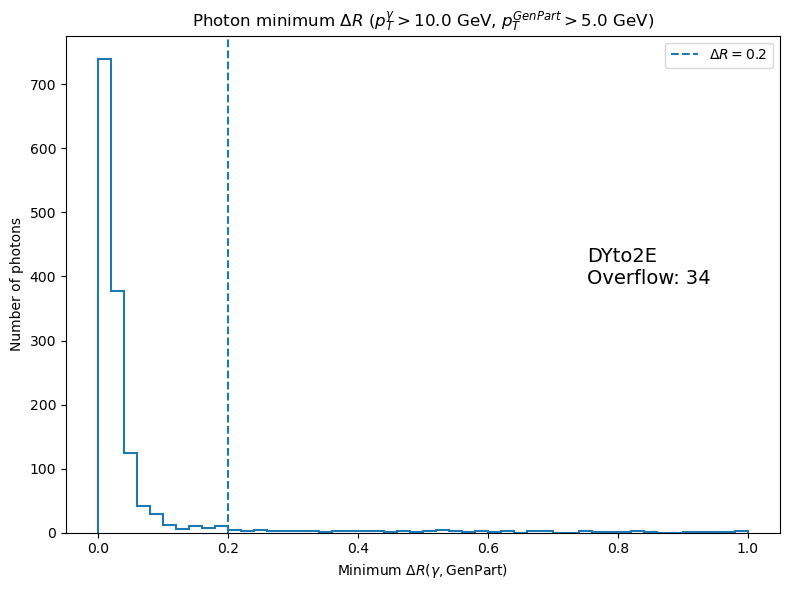

In [29]:
plot_photon_min_dr(events_DYE, label = "DYto2E")

In [60]:
import awkward as ak

def is_allowed_parent(pdgId):
    apdg = abs(pdgId)

    # Quarks: d, u, s, c, b, t
    is_quark = (apdg >= 1) & (apdg <= 6)

    # Gluon
    is_gluon = apdg == 21

    # Leptons: e, nu_e, mu, nu_mu, tau, nu_tau
    is_lepton = (
        (apdg == 11) |
        (apdg == 13) |
        (apdg == 15))

    # Bosons: gamma, Z, W, Higgs
    is_boson = (
        (apdg == 22) |
        (apdg == 23) |
        (apdg == 24) |
        (apdg == 25)
    )

    return is_quark | is_gluon | is_lepton | is_boson

def photon_parentage_ok(gen_pho, gen, max_depth=30):

    mother_idx = gen_pho.genPartIdxMother

    # Start with all photons considered valid
    history_ok = ak.ones_like(mother_idx, dtype=bool)

    # Photons with a valid mother need to be followed
    active = mother_idx >= 0

    current_idx = mother_idx

    for _ in range(max_depth):

        if not ak.any(active):
            break

        # Prevent -1 from being used as an index
        safe_idx = ak.where(active, current_idx, 0)

        ancestor = gen[safe_idx]

        ancestor_pdgId = ancestor.pdgId

        # Is this ancestor an allowed particle?
        allowed = is_allowed_parent(ancestor_pdgId)

        # If an active ancestor is NOT allowed,
        # reject this photon.
        history_ok = history_ok & ak.where(active, allowed, True)

        # Move to the next mother only if current ancestor
        # was allowed and has a valid mother.
        next_idx = ancestor.genPartIdxMother

        active = (active & allowed & (next_idx >= 0))

        current_idx = next_idx

    return history_ok


def photon_isolation_ok(gen_pho, gen, pt_min=5.0, dr_min=0.2):

    # Other generated particles
    other = gen[(gen.pt > pt_min) & (abs(gen.pdgId) != 22)]

    pairs = ak.cartesian({"pho": gen_pho, "part": other}, axis=1, nested=True)

    pho = pairs["pho"]
    part = pairs["part"]

    deta = pho.eta - part.eta

    # Delta phi wrapped to [-pi, pi]
    dphi = np.arctan2(np.sin(pho.phi - part.phi), np.cos(pho.phi - part.phi))

    dr = np.sqrt(deta**2 + dphi**2)

    # For each photon require ALL particles to have
    # DeltaR > 0.2
    return ak.all(dr > dr_min, axis=2)


gen = events_DYE.GenPart

gen_pho = gen[abs(gen.pdgId) == 22]


pho_kin = ((gen_pho.pt > 10.0) & (abs(gen_pho.eta) < 3.0))

pho_history = photon_parentage_ok(gen_pho, gen)

pho_iso = photon_isolation_ok(gen_pho, gen, pt_min=5.0, dr_min=0.2)

overlap_photons = gen_pho[pho_kin & pho_history & pho_iso]

remove_event = ak.num(overlap_photons, axis=1) > 0

keep_event = ~remove_event



In [95]:
import numpy as np
import awkward as ak

def photon_nearby_particles(
    events,
    photon_pt_min=10.0,
    photon_eta_max=3.0,
    other_pt_min=5.0,
    dr_max=0.1,
):

    gen = events.GenPart
    apdg = abs(gen.pdgId)

    photon_mask = ((apdg == 22) & (gen.pt > photon_pt_min) & (abs(gen.eta) < photon_eta_max))

    photons = gen[photon_mask]

    history_ok = photon_parentage_ok(photons, gen)

    photons = photons[history_ok]

    is_quark = (
        (apdg >= 1) &
        (apdg <= 6)
    )

    is_gluon = (
        apdg == 21
    )

    is_lepton = (
        (apdg == 11) |
        (apdg == 13) |
        (apdg == 15)
    )

    is_boson = (
        (apdg == 23) |
        (apdg == 24) |
        (apdg == 25)
    )

    allowed_nearby = (
        is_quark |
        is_gluon |
        is_lepton |
        is_boson
    )

    particles = gen[allowed_nearby & (gen.pt > other_pt_min)]

    pairs = ak.cartesian({"pho": photons, "part": particles}, axis=1, nested=True)

    pho = pairs["pho"]
    part = pairs["part"]

    deta = pho.eta - part.eta

    dphi = np.arctan2(
        np.sin(pho.phi - part.phi),
        np.cos(pho.phi - part.phi),
    )

    dr = np.sqrt(deta**2 + dphi**2)

    close = dr < dr_max

    nearby = part[close]
    nearby_dr = dr[close]

    return photons, nearby, nearby_dr

In [96]:
def print_nearby_particles(
    events,
    photon_pt_min=10.0,
    photon_eta_max=3.0,
    other_pt_min=5.0,
    dr_max=0.1,
):
    photons, nearby, nearby_dr = photon_nearby_particles(
        events,
        photon_pt_min=photon_pt_min,
        photon_eta_max=photon_eta_max,
        other_pt_min=other_pt_min,
        dr_max=dr_max,
    )

    particle_names = {
        1: "d",
        2: "u",
        3: "s",
        4: "c",
        5: "b",
        6: "t",
        21: "gluon",
        11: "e",
        13: "mu",
        15: "tau",
        23: "Z",
        24: "W",
        25: "H",
    }

    print(
        f"{'Event':>8} "
        f"{'Photon':>8} "
        f"{'Pho pT':>10} "
        f"{'Particle':>10} "
        f"{'Part pT':>10} "
        f"{'dR':>10}"
    )
    print("-" * 62)

    for iev, (event_photons, event_particles, event_dr) in enumerate(
        zip(photons, nearby, nearby_dr)
    ):

        for ipho, (pho, particles, drs) in enumerate(
            zip(event_photons, event_particles, event_dr)
        ):

            # Extract scalar photon pT directly
            pho_pt = float(pho["pt"])

            for particle, dr in zip(particles, drs):

                pdgid = int(particle["pdgId"])
                part_pt = float(particle["pt"])
                dr_value = float(dr)

                name = particle_names.get(abs(pdgid), str(pdgid))

                # Add "bar" for antiparticles
                if pdgid < 0:
                    if abs(pdgid) in [1, 2, 3, 4, 5, 6]:
                        name += "bar"
                    elif abs(pdgid) == 11:
                        name = "e+"
                    elif abs(pdgid) == 13:
                        name = "mu+"
                    elif abs(pdgid) == 15:
                        name = "tau+"

                print(
                    f"{iev:8d} "
                    f"{ipho:8d} "
                    f"{pho_pt:10.2f} "
                    f"{name:>10} "
                    f"{part_pt:10.2f} "
                    f"{dr_value:10.4f}"
                )

In [98]:
print_nearby_particles(events_TTG1Jets)

   Event   Photon     Pho pT   Particle    Part pT         dR
--------------------------------------------------------------
      10        0      18.62          u      63.75     0.0926
      10        0      18.62      gluon      36.25     0.0726
      10        1      18.69      gluon      36.25     0.0828
      18        0      20.25         e+      16.94     0.0684
      18        1      21.12         e+      16.94     0.0428
      70        0      29.31          W     415.00     0.0352
      70        0      29.31         e+     364.00     0.0843
      70        0      29.31         e+     351.00     0.0821
      70        1      34.75          t     453.00     0.0900
      70        1      34.75          W     415.00     0.0568
      70        1      34.75         e+     364.00     0.0858
      70        1      34.75         e+     351.00     0.0856
      90        0      31.38          u      24.00     0.0625
     101        2      64.25          W     184.50     0.0439
     11

In [116]:
print_genpart_tree(events.GenPart, 5629)


EVENT 5629
├── u~  pt=0.00  eta=22784.00  phi=0.00  mass=0.00
│   └── Z0  pt=0.00  eta=-38.88  phi=-1.58  mass=90.25
│       └── Z0  pt=2.00  eta=-5.66  phi=2.48  mass=90.25
│           └── Z0  pt=1.71  eta=-5.81  phi=2.37  mass=90.25
│               └── Z0  pt=3.44  eta=-5.11  phi=0.97  mass=90.25
│                   ├── e+  pt=46.50  eta=-1.86  phi=1.56  mass=0.00
│                   │   ├── gamma  pt=20.88  eta=-1.90  phi=1.68  mass=0.00
│                   │   └── e+  pt=25.81  eta=-1.83  phi=1.46  mass=0.00
│                   ├── e-  pt=27.81  eta=-1.90  phi=-1.61  mass=0.00
│                   │   └── e-  pt=27.62  eta=-1.90  phi=-1.61  mass=0.00
│                   │       ├── e-  pt=27.62  eta=-1.90  phi=-1.61  mass=0.00
│                   │       └── gamma  pt=0.00  eta=-1.88  phi=-1.57  mass=0.00
│                   └── gamma  pt=16.06  eta=-1.84  phi=-1.43  mass=0.00
└── u  pt=0.00  eta=-23040.00  phi=0.00  mass=0.00


In [30]:
def delta_r(obj1, obj2):
    dphi = np.arctan2(np.sin(obj1["phi"] - obj2["phi"]), np.cos(obj1["phi"] - obj2["phi"]))
    deta = obj1["eta"] - obj2["eta"]
    return np.sqrt(deta**2 + dphi**2)

In [31]:
delta_r(gen_pho[0][0], gen_pho[0][1])

0.0717423087531013